In [1]:
from mpi4py import MPI
import coqui

import numpy as np
from scipy.constants import physical_constants
HARTREE_EV = physical_constants['Hartree energy in eV'][0]

import matplotlib.pyplot as plt

# Create CoQui MPI handler and set logging verbosity in the beginning
coqui_mpi = coqui.MpiHandler()
coqui.set_verbosity(coqui_mpi, output_level=1)

--------------------------------------------------------------------------
Ignoring value for oob_tcp_if_exclude on ccqlin065 (10.250.112.0/20: Did not find interface matching this subnet).
(You can safely ignore this message.)
--------------------------------------------------------------------------


# Constrained random phase approximation (cRPA)

<figure style="text-align: center;">
 <img src="../../images/svo_crpa_cartoon_ver2.png" alt="cRPA svo" width="40%">
 <figcaption><em>Figure&nbsp;1:</em> Different types of screening processes, involving transitions between the target subspace $\mathcal{C}$ and the environment $\mathcal{B}\backslash\mathcal{C}$.</figcaption>
</figure>

In this notebook, we compute effective Coulomb interactions for a chosen Hilbert subspace using the constrained random phase approximation (cRPA).

In cRPA, the full Hilbert space $\mathcal{B}$ is partitioned into a target subspace $\mathcal{C}$ and the environment $\mathcal{B}\backslash\mathcal{C}$ which contains all remaining degrees of freedom. This partitioning gives rise to three types of screening processes, illustrated in Figure 1: (1) transitions between $\mathcal{C}$ and $\mathcal{B}\backslash\mathcal{C}$, (2) transitions within the environment $\mathcal{B}\backslash\mathcal{C}$, and (3) transitions within the subspace $\mathcal{C}$.

The cRPA screened interaction

$$
U_{\mathrm{cRPA}}(\mathbf{q}, i\Omega_{n}) = V(\mathbf{q}) + V(\mathbf{q})\Pi_{\mathrm{cRPA}}(\mathbf{q}, i\Omega_n)W(\mathbf{q}, i\Omega_{n})
$$

is defined via a *partially* screened polarization $\Pi_{\mathrm{cRPA}}$ in which screening processes internal to $\mathcal{C}$ are excluded:

$$
\Pi_{\mathrm{cRPA}}(\mathbf{q}, i\Omega_n) = \Pi_{\mathrm{RPA}}(\mathbf{q}, i\Omega_n) - \Pi^{(3)}_{\mathrm{RPA}}(\mathbf{q}, i\Omega_n).
$$

Physically, $U_{\mathrm{cRPA}}$ can be viewed as an effective bare Coulomb interaction for the subspace $\mathcal{C}$. 
When constructing low-energy models restricted to $\mathcal{C}$, removing the intra-subspace screening ensures that these processes are not double-counted, since they will be treated explicitly when solving the effective model. 

**What's covered in this notebook**
1. How to compute cRPA screened interactions

2. How to manipulate dynamic correlation function via `IAFT` class

2. How to extract Hubbard–Kanamori parameterization from cRPA results

3. How the Wannier window affects static and dynamic effective interactions


First, copy the pre-computed inputs required for this notebook.

This prepares local copies of:

- `svo_222/` (QE and Wannier90 outputs for 2x2x2 SrVO$_3$)

In [ ]:
%%bash
python copy_notebook_inputs.py

Removed directory: svo_222
Copied: data/qe_inputs/svo/222 -> svo_222
Notebook inputs are ready.


### Section 1: cRPA

<figure style="text-align: center;">
 <img src="../../images/coqui_workflow_crpa.png" alt="cRPA workflow in CoQuí" width="60%">
 <figcaption>cRPA workflow in CoQuí.</figcaption>
</figure>

As illustrated in Figure 2, the cRPA workflow in CoQuí closely parallels the GW workflow. Both approaches start from a second-quantized interacting Hamiltonian compressed in the THC representation and take advantages of efficient imaginary-axis Fourier transform using the DLR basis. The target subspace $\mathcal{C}$ is defined using maximally localized Wannier functions (MLWFs).

Starting from an interacting Hamiltonian stored in a `ThcCoulomb` instance, cRPA can be performed through a single call to  `downfold_coulomb`, which carries out the downfolding of the Coulomb interaction into the $\mathcal{C}$ subspace defined by the MLWFs:

>```python
>coqui.downfold_coulomb(h_int: ThcCoulomb, params: dict) -> Tuple[Vloc, Uloc_w]
>```

Function inputs:
- `h_int`: `ThcCoulomb` instance for the Coulomb Hamiltonian

- `params`: dictionary of cRPA parameters. Key parameters include:

    - `outdir` (default: `"."`): output directory

    - `prefix` (required): checkpoint prefix

    - `wannier_file` (required): MLWF HDF5 archive that defines the target subspace $\mathcal{C}$.

    - `screen_type` (required): screening prescription that defines the irreducible polarizability $\Pi(\mathbf{q},i\Omega_{n})$ used to compute the screened interaction $W$. Available options include: `"crpa"`, `"rpa"`, etc.

    - `greens_func_source` (required): determines whether polarization is evaluated using mean-field or interacting electronic structure:
        - `"mf"`: uses the mean-field Green's function $G_0$ from the underlying `Mf` object. If no checkpoint is available, the mean-field Green's function is generated on the fly using the supplied `beta` parameter.

        - `"scf"`: uses the interacting Green's function $G$ obtained from a self-consistent MBPT calculation read from an exisiting checkpoint

    - `beta` (default: 1000): inverse temperature (in a.u.$^{-1}$). This parameter is used only when there is no checkpoint to read the Green's function from.

Returned outputs:
- `Vloc`: bare local tensor $V_{abcd}$ in the MLWF basis, with shape $(N_{\mathrm{wann}}, N_{\mathrm{wann}}, N_{\mathrm{wann}}, N_{\mathrm{wann}})$

- `Uloc_w`: dynamic screened interaction $U_{abcd}(i\Omega_n)$ in the MLWF basis, with shape $(N^{+}_{\mathrm{freq}}, N_{\mathrm{wann}}, N_{\mathrm{wann}}, N_{\mathrm{wann}}, N_{\mathrm{wann}})$

Here, $N_{\mathrm{wann}}$ denotes the number of MLWFs in the target subspace. The frequency dimension $N^{+}_{\mathrm{freq}}$ contains only the *positive* bosonic Matsubara frequencies on the DLR mesh. Since the screened interaction satisfies the particle-hole symmetry relation
$$
U(-i\Omega_{n}) = U(i\Omega_{n})
$$
the negative-frequency components are redundant and therefore are not stored explicitly.

> The returned downfolded interactions are also stored in the checkpoint `{outdir}/{prefix}.mbpt.h5` under the group `scf/iter{X}/downfolded_model/` where `X` is the iteration number of the self-consistent MBPT calculation from which the Green's function is read.


#### 🔹 Example: cRPA screened interaction for V $t_{2g}$ on SrVO$_3$

In [2]:
nbnd = 100
mf_params = {
    "prefix": "svo",
    "outdir": "svo_222/out",
    "nbnd": nbnd
}
mf = coqui.make_mf(coqui_mpi, params=mf_params, mf_type="qe")

thc_params = {
    "thresh": 1e-3
}
thc = coqui.make_thc_coulomb(mf=mf, params=thc_params)

crpa_params = {
    "screen_type": "crpa",
    "greens_func_source": "mf",
    "prefix": f"crpa_{nbnd}", 
    "wannier_file": "svo_222/mlwf/svo.mlwf.h5", 
}
Vloc, Uloc_iw = coqui.downfold_coulomb(h_int=thc, params=crpa_params)

  Quantum ESPRESSO reader
  -----------------------
  Number of spins                = 1
  Number of polarizations        = 1
  Number of bands                = 100
  Monkhorst-Pack mesh            = (2,2,2)
  K-points                       = 8 total, 4 in the IBZ
  Number of electrons            = 41.0
  Electron density energy cutoff = 360.000 a.u. | FFT mesh = (45,45,45)
  Wavefunction energy cutoff     = 51.704 a.u. | FFT mesh = (23,23,23), Number of PWs = 6859


╔═╗╔═╗╔═╗ ╦ ╦╦  ╔╦╗┬ ┬┌─┐╔═╗┌─┐┬ ┬┬  ┌─┐┌┬┐┌┐ 
║  ║ ║║═╬╗║ ║║   ║ ├─┤│  ║  │ ││ ││  │ ││││├┴┐
╚═╝╚═╝╚═╝╚╚═╝╩   ╩ ┴ ┴└─┘╚═╝└─┘└─┘┴─┘└─┘┴ ┴└─┘

  Algorithm                       = ISDF
  THC integrals access            = incore
  Found precomputed THC integrals = false
  --> CoQuí will compute THC integrals.

  ERI::thc Computation Details
  ----------------------------
  Energy cutoff                = 144.0 a.u. | FFT mesh = (39,39,39), Number of PWs = 31463
  Threshold                    = 0.001

**************************

Check the output log and identify the orbital-averaged Coulomb interactions.

 - What are the orbital-averaged *bare* and *static screened* interactions?

 - Are the computed values consistent with those reported in literature?

Special care should be taken for the screened interaction, since it depends sensitively on both the number of bands (`nbnd`) and the k-point mesh used in the polarization calculation. Convergence with respect to these parameters should always be checked carefully.

By contrast, the *bare* interaction is determined solely by the spatial localization of MLWF and is independent of the number of unoccupied bands included in the polarization. It has only a mild dependence on the size of the k-mesh through the Wannierization procedure. 

 > Note: Reference cRPA values [[1]](https://journals.aps.org/prb/abstract/10.1103/PhysRevB.86.165105): bare $U\sim16$ eV, screened $U(0)\sim3.5$ eV, and $J\sim0.6$ eV.

 > Note: Small imaginary components may appear if MLWFs are not strictly real, often due to limited k-mesh size in Wannierization.


### Section 2: Manipulate dynamical correlation functions on the imaginary axis

Post-processing of correlation functions is an essential part of many-body workflows. After a CoQui simulation, users often need to (i) inspect frequency dependence of quantities such as screened interactions or self-energies, (ii) transform between imaginary-time and Matsubara-frequency representations for analysis, and (iii) evaluate functions on meshes different from the native DLR grid.

In CoQuí, correlation functions stored in checkpoints or returned directly by CoQui functions are represented on DLR sampling grids, either in imaginary time $\tau$ or Matsubara frequency $i\omega_n$. For analysis and visualization, it is therefore useful to manipulate these objects directly on the imaginary axis.

CoQuí provides the `IAFT` class for this purpose. `IAFT` encapsulates the DLR basis and offers utilities to:
- generate fermionic/bosonic $\tau$ and $i\omega_n$ meshes,

- perform Fourier transforms between $\tau$ and $i\omega_n$,

- interpolate correlation functions to arbitrary points on the imaginary axis.

Constructor:
>```python
>IAFT.from_coqui_chkpt(chkpt_h5: str) -> IAFT
>```

- `chkpt_h5` (required): CoQuí checkpoint file.

The constructor reads DLR basis metadata from the checkpoint and returns an initialized `IAFT` object ready for transformations and mesh generation.

Use Python help to inspect the available APIs and docstrings:
>```python
>help(IAFT)
>```


#### 🔹 Example:

In [14]:
from coqui.utils.imag_axes_ft import IAFT

# --- Initialization ---
iaft = coqui.IAFT.from_coqui_chkpt("crpa_100.mbpt.h5")

# --- Mesh points ---
tau_mesh_fermion, tau_mesh_boson = iaft.tau_mesh(stats='fermion'), iaft.tau_mesh(stats='boson')
wn_mesh_fermion, wn_mesh_boson = iaft.wn_mesh(stats='fermion'), iaft.wn_mesh(stats='boson')

# --- Fourier transform ---
#help(iaft.w_to_tau)
Uloc_t = iaft.w_to_tau(Uloc_iw, stats='boson', ph_sym=True)

# --- Interpolation ---
Uloc_beta = iaft.tau_interpolate(Uloc_t, 0, stats='boson', ph_sym=True)

  Mesh details on the imaginary axis
  ----------------------------------
  Discrete Lehmann Representation
  Beta                   = 1000.0 a.u.
  Frequency cutoff       = 4.128302429370114 a.u.
  Lambda                 = 4128.302429370115
  Precision              = medium (i.e. eps = 1e-10)
  nt_f, nt_b, nw_f, nw_b = 62, 62, 62, 63



#### 🔹 Example: Plotting the frequency dependence of screened interactions

In this example, we plot the frequency dependence of representative matrix elements of the cRPA screened interaction:

$$
U_{\mathrm{cRPA}} = V_{abcd} + U_{abcd}(i\Omega_n)
$$

where $V_{abcd}$ is the bare interaction and $U_{abcd}(i\Omega_n)$ is the dynamic contribution from cRPA downfolding.

Tasks:
1. Initialize `IAFT` from the checkpoint and build the positive bosonic mesh.

2. Use this mesh to plot the frequency dependence of representative elements, such as diagonal $U_{aaaa}$ and inter-orbital $U_{abab}$, from the computed `Uloc_iw`.

3. Optional: set `screen_type="rpa"` and compare the resulting screened interaction with the `"crpa"` results.

Notes:
- CoQuí outputs are in atomic units; Use `HARTREE_EV` to convert from Hartree to eV. 

- Positive boconic Matsubara frequencies can be generated with:
    >```python
    >wn_mesh_b = iaft.wn_mesh(stats='b', positive_only=True)
    >```


  Mesh details on the imaginary axis
  ----------------------------------
  Discrete Lehmann Representation
  Beta                   = 1000.0 a.u.
  Frequency cutoff       = 4.128302429370114 a.u.
  Lambda                 = 4128.302429370115
  Precision              = medium (i.e. eps = 1e-10)
  nt_f, nt_b, nw_f, nw_b = 62, 62, 62, 63



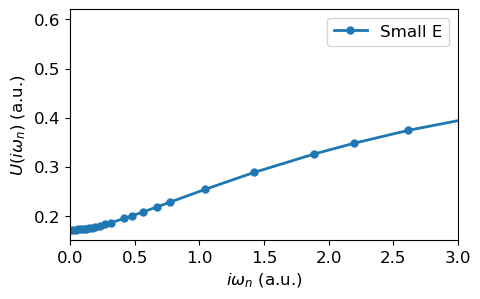

In [ ]:
#from coqui.utils.imag_axes_ft import IAFT

iaft = coqui.IAFT.from_coqui_chkpt("crpa_100.mbpt.h5")

iw_mesh = iaft.wn_mesh(stats='b', positive_only=True) * np.pi / iaft.beta

fig, ax = plt.subplots(1, figsize=(5,3))
ax.plot(iw_mesh, (Vloc[0,0,0,0]+Uloc_iw[:,0,0,0,0]).real,
        linewidth=2, marker='o', markersize=5, label='Small E')
ax.set_xlim(0,3)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.set_xlabel('$i\omega_{n}$ (a.u.)', fontsize=12)
ax.set_ylabel('$U(i\omega_{n})$ (a.u.)', fontsize=12)
ax.legend(fontsize=12)
plt.show()

#### 🔹 Post-processing / interpretation: extract Hubbard–Kanamori parameters

The local interaction from `downfold_coulomb` is a four-index tensor $U_{abcd}(i\Omega_n)$ in the MLWF basis. For many applications, this is reduced to Hubbard–Kanamori parameters: $U$, $U'$, and Hund couplings.

Tasks:
1. Build static tensor from bare $V$ and screened part at $\Omega_n=0$.
2. Extract $U$, $U'$, $J$ from $U_{abcd}(0)$:
$$
U = \langle U_{iiii}(0)\rangle_i,\quad
U' = \langle U_{iijj}(0)\rangle_{i\neq j},\quad
J_{\text{spin-flip}} = \langle U_{ijji}(0)\rangle_{i\neq j},\quad
J_{\text{pair-hopping}} = \langle U_{ijij}(0)\rangle_{i\neq j}.
$$
3. Check rotational-invariance relations:
$$
U' \approx U - 2J,\qquad
J_{\text{spin-flip}} = J_{\text{pair-hopping}} = J.
$$
4. Compare with CoQuí log summaries and literature values.


In [19]:
# Your task: Write a function to return orbital-average parametrization of the Hubbard Kanamori model
def orb_avg_coulomb(V_abcd):
    norb = V_abcd.shape[0]

    U = 0
    for i in range(norb):
        U += V_abcd[i,i,i,i]
    U /= norb

    Up = 0
    for i in range(norb):
        for j in range(i+1,norb):
            if i!=j:
                Up += V_abcd[i,i,j,j]
    Up /= (norb * (norb-1) ) / 2

    J_pair = 0
    for i in range(norb):
        for j in range(i+1,norb):
            if i!=j:
                J_pair += V_abcd[i,j,i,j]
    J_pair /= (norb * (norb-1) ) / 2

    J_spin = 0
    for i in range(norb):
        for j in range(i+1,norb):
            if i!=j:
                J_spin += V_abcd[i,j,j,i]
    J_spin /= (norb * (norb-1) ) / 2

    return U, Up, J_pair, J_spin

In [5]:
V, Vp, J_pair, J_spin = orb_avg_coulomb(Vloc.real * HARTREE_EV)
U, Up, J_pair_scr, J_spin_scr = orb_avg_coulomb(Uloc_iw[0].real * HARTREE_EV)
print("Small window")
print("-"*13)
print("Bare Interactions")
print(f"  - Intra-orbital: {V}")
print(f"  - Inter-orbital: {Vp}")
print(f"  - Pair hopping: {J_pair}")
print(f"  - Spin flip:    {J_spin}")
print("Screened Interactions")
print(f"  - Intra-orbital: {V+U}")
print(f"  - Inter-orbital: {Vp+Up}")
print(f"  - Pair hopping: {J_pair+J_pair_scr}")
print(f"  - Spin flip:    {J_spin+J_spin_scr}\n")

Small window
-------------
Bare Interactions
  - Intra-orbital: 16.3812862745328
  - Inter-orbital: 15.018802421818721
  - Pair hopping: 0.6474021427216554
  - Spin flip:    0.6474021427216554
Screened Interactions
  - Intra-orbital: 4.950152089523241
  - Inter-orbital: 3.8272433543044677
  - Pair hopping: 0.535574020472688
  - Spin flip:    0.535574020472688



### Example: Effect of the Wannier energy window

[TODO This example needs to be restructured.]

In cRPA, the low-energy subspace depends on the Wannier window used to build projectors. Enlarging this window often gives more localized MLWFs, which tends to increase both bare $V$ and dynamic screened interaction.

The target model remains the three V $t_{2g}$ orbitals, but projector character changes when the Wannierization window changes. This directly affects both static and dynamic effective interactions.

Use the same `downfold_coulomb` workflow and parameters as before, and change only the projector source:
- small window: `../../data/qe_inputs/svo/222/mlwf/svo.mlwf.h5`
- larger window: `../../data/qe_inputs/svo/222/mlwf_dp/svo.mlwf.h5`


Reuse the same `crpa_params` dictionary and update only `wannier_file` to the larger-window archive.

Tasks:
1. Re-run cRPA with the larger-window MLWF archive at `../../data/qe_inputs/svo/222/mlwf_dp/`.
 > Clarification: The Wannierization window is larger, but the downfolded model still uses the three V $t_{2g}$ orbitals.
2. Extract static Hubbard–Kanamori parameters $(U, U', J)$.
3. Compare with the smaller-window result.
4. Discuss:
 - Is bare interaction increased as expected?
 - How does frequency dependence change? Plot both curves together.

Compare both windows side-by-side using:
- static summaries from the printed Hubbard–Kanamori parameters
- dynamic comparison from overlaid $U(i\Omega_n)$ curves

 > Note: For larger-window MLWFs, $U(i\Omega_n)$ may show an upturn near $\Omega_n=0$ because residual low-energy screening can remain more visible in the projected subspace.


In [17]:
nbnd = 100
# --- Phase 1: Problem setup ---
mf_params = {
    "prefix": "svo",
    "outdir": "svo_222/out",
    "nbnd": nbnd
}
mf = coqui.make_mf(coqui_mpi, params=mf_params, mf_type="qe")

thc_params = {
    "thresh": 1e-3
}
thc = coqui.make_thc_coulomb(mf=mf, params=thc_params)

# --- Phase 2: Simulation (cRPA) ---
crpa_params = {
    "screen_type": "crpa",
    "greens_func_source": "mf",
    "prefix": f"crpa_dp_{nbnd}",
    "wannier_file": "svo_222/mlwf_dp/svo.mlwf.h5",
    "beta": 300,
}
Vloc2, Uloc2_iw = coqui.downfold_coulomb(h_int=thc, params=crpa_params)

  Quantum ESPRESSO reader
  -----------------------
  Number of spins                = 1
  Number of polarizations        = 1
  Number of bands                = 100
  Monkhorst-Pack mesh            = (2,2,2)
  K-points                       = 8 total, 4 in the IBZ
  Number of electrons            = 41.0
  Electron density energy cutoff = 360.000 a.u. | FFT mesh = (45,45,45)
  Wavefunction energy cutoff     = 51.704 a.u. | FFT mesh = (23,23,23), Number of PWs = 6859


╔═╗╔═╗╔═╗ ╦ ╦╦  ╔╦╗┬ ┬┌─┐╔═╗┌─┐┬ ┬┬  ┌─┐┌┬┐┌┐ 
║  ║ ║║═╬╗║ ║║   ║ ├─┤│  ║  │ ││ ││  │ ││││├┴┐
╚═╝╚═╝╚═╝╚╚═╝╩   ╩ ┴ ┴└─┘╚═╝└─┘└─┘┴─┘└─┘┴ ┴└─┘

  Algorithm                       = ISDF
  THC integrals access            = incore
  Found precomputed THC integrals = false
  --> CoQuí will compute THC integrals.

  ERI::thc Computation Details
  ----------------------------
  Energy cutoff                = 144.0 a.u. | FFT mesh = (39,39,39), Number of PWs = 31463
  Threshold                    = 0.001

**************************

In [20]:
V, Vp, J_pair, J_spin = orb_avg_coulomb(Vloc2.real * HARTREE_EV)
U, Up, J_pair_scr, J_spin_scr = orb_avg_coulomb(Uloc2_iw[0].real * HARTREE_EV)
print("Large window")
print("-"*13)
print("Bare Interactions")
print(f"  - Intra-orbital: {V}")
print(f"  - Inter-orbital: {Vp}")
print(f"  - Pair hopping: {J_pair}")
print(f"  - Spin flip:    {J_spin}")
print("Screened Interactions")
print(f"  - Intra-orbital: {V+U}")
print(f"  - Inter-orbital: {Vp+Up}")
print(f"  - Pair hopping: {J_pair+J_pair_scr}")
print(f"  - Spin flip:    {J_spin+J_spin_scr}")

Large window
-------------
Bare Interactions
  - Intra-orbital: 19.36659410953616
  - Inter-orbital: 17.690446448325847
  - Pair hopping: 0.8457418452598953
  - Spin flip:    0.8457418452598953
Screened Interactions
  - Intra-orbital: 12.553366672937567
  - Inter-orbital: 11.033437297206284
  - Pair hopping: 0.7368709707677148
  - Spin flip:    0.7368709707677148


  Mesh details on the imaginary axis
  ----------------------------------
  Discrete Lehmann Representation
  Beta                   = 300.0 a.u.
  Frequency cutoff       = 4.128302429370114 a.u.
  Lambda                 = 1238.4907288110344
  Precision              = medium (i.e. eps = 1e-10)
  nt_f, nt_b, nw_f, nw_b = 52, 52, 52, 53



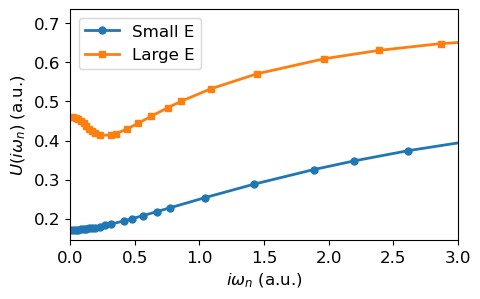

In [24]:
iaft2 = coqui.IAFT.from_coqui_chkpt("crpa_dp_100.mbpt.h5")
iw_mesh2 = iaft2.wn_mesh(stats='b', positive_only=True) * np.pi / iaft2.beta

fig, ax = plt.subplots(1, figsize=(5,3))
ax.plot(iw_mesh, (Vloc[0,0,0,0]+Uloc_iw[:,0,0,0,0]).real,
        linewidth=2, marker='o', markersize=5, label='Small E')
ax.plot(iw_mesh2, (Vloc2[0,0,0,0]+Uloc2_iw[:,0,0,0,0]).real,
        linewidth=2, marker='s', markersize=5, label='Large E')
ax.set_xlim(0,3)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.set_xlabel('$i\omega_{n}$ (a.u.)', fontsize=12)
ax.set_ylabel('$U(i\omega_{n})$ (a.u.)', fontsize=12)
ax.legend(fontsize=12)
plt.show()